Separate the meta data

head -9 Counts.csv | datamash transpose -t, | tail -n +3 | cut -d, -f1,2,4- | sed '1isample,subject,type,study,group,age,sex,plate' | sed 's/Unnamed: [[:digit:]]\{1,2\}_level_.//g' > manifest.csv 



head -1 Counts.csv | cut -d, -f1,3- > tmp1.csv 

tail -n +10 Counts.csv | cut -d, -f1,3- >> tmp1.csv 

cat tmp1.csv | datamash transpose -t, > tmp2.csv

head -1 tmp2.csv > data.csv

tail -n +2 tmp2.csv | sort -t, -k1,1 >> data.csv

sed -i '1s/^id/sample/' data.csv


Just a matrix with peptide ids and sample ids.

In [6]:
%%time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
manifest = pd.read_csv('manifest.csv')
data = pd.read_csv('data.csv')


CPU times: user 1min 16s, sys: 2.44 s, total: 1min 19s
Wall time: 1min 19s


In [7]:
# Show the first few rows of each to inspect structure
manifest.head()


,sample,subject,type,study,group,age,sex,plate
0,14078-01,14078-01,glioma serum,IPS,case,60.0,M,1
1,14078-01dup,14078-01,glioma serum,IPS,case,60.0,M,1
2,14118-01,14118-01,glioma serum,IPS,case,61.0,M,1
3,14118-01dup,14118-01,glioma serum,IPS,case,61.0,M,1
4,14127-01,14127-01,glioma serum,IPS,case,63.0,M,1


In [8]:
data.head()


,sample,1,2,3,4,5,6,7,8,9,...,128278,128279,128280,128281,128282,128283,128284,128285,128286,128287
0,024JCM,0,0,0,0,1,0,53,0,0,...,0,0,0,0,1,0,0,0,2,0
1,024JCMdup,0,2,0,0,44,0,3,0,0,...,3,0,1,193,0,0,0,0,2,0
2,043MPL,0,20,0,0,23,0,31,0,0,...,0,0,0,20,6,4,0,4,3,0
3,043MPLdup,0,16,0,0,10,0,4,0,0,...,7,0,3,4,13,8,0,0,7,0
4,074KBP,0,0,0,0,31,0,52,0,18,...,0,0,0,0,0,0,1,0,39,7


In [9]:
import numpy as np

# Merge manifest and data on 'sample'
data_annot = pd.merge(manifest[['sample', 'subject', 'plate']], data, on='sample', how='inner')

# Classify samples
def classify_sample(s):
    if s.startswith('CSE'):
        return 'control'
    elif s.startswith('Blank'):
        return 'blank'
    elif s.startswith('PLib'):
        return 'phage_library'
    else:
        return 'subject'

data_annot['class'] = data_annot['sample'].apply(classify_sample)

# Fill missing values in peptide counts with 0
peptide_cols = data_annot.columns.difference(['sample', 'subject', 'plate', 'class'])
data_annot[peptide_cols] = data_annot[peptide_cols].fillna(0).astype(int)

# Check class distribution and a sample of the annotated data
data_annot['class'].value_counts(), data_annot.head()

(class
 subject          1008
 blank              93
 control            24
 phage_library      24
 Name: count, dtype: int64,
         sample   subject  plate  1    2  3  4  5  6   7  ...  128279  128280  \
 0     14078-01  14078-01      1  0    0  0  0  1  0   2  ...       0       1   
 1  14078-01dup  14078-01      1  0   26  0  0  0  0   0  ...       0       0   
 2     14118-01  14118-01      1  0    0  0  0  1  0  81  ...       0       0   
 3  14118-01dup  14118-01      1  0    0  0  0  2  0   1  ...       0       0   
 4     14127-01  14127-01      1  0  161  0  0  0  0   0  ...       0       1   
 
    128281  128282  128283  128284  128285  128286  128287    class  
 0       0       0       0       0       0       0      21  subject  
 1      10      57       4       0       0       0       2  subject  
 2      21       1       0       0       0       0       0  subject  
 3       0       1       0       5       0      12       0  subject  
 4       0      31       0       0 

/var/folders/cz/x4nfh_790yn58j4sc5qp7wkc0000gn/T/ipykernel_37003/3026358710.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_annot['total_count'] = data_annot[peptide_cols].sum(axis=1)


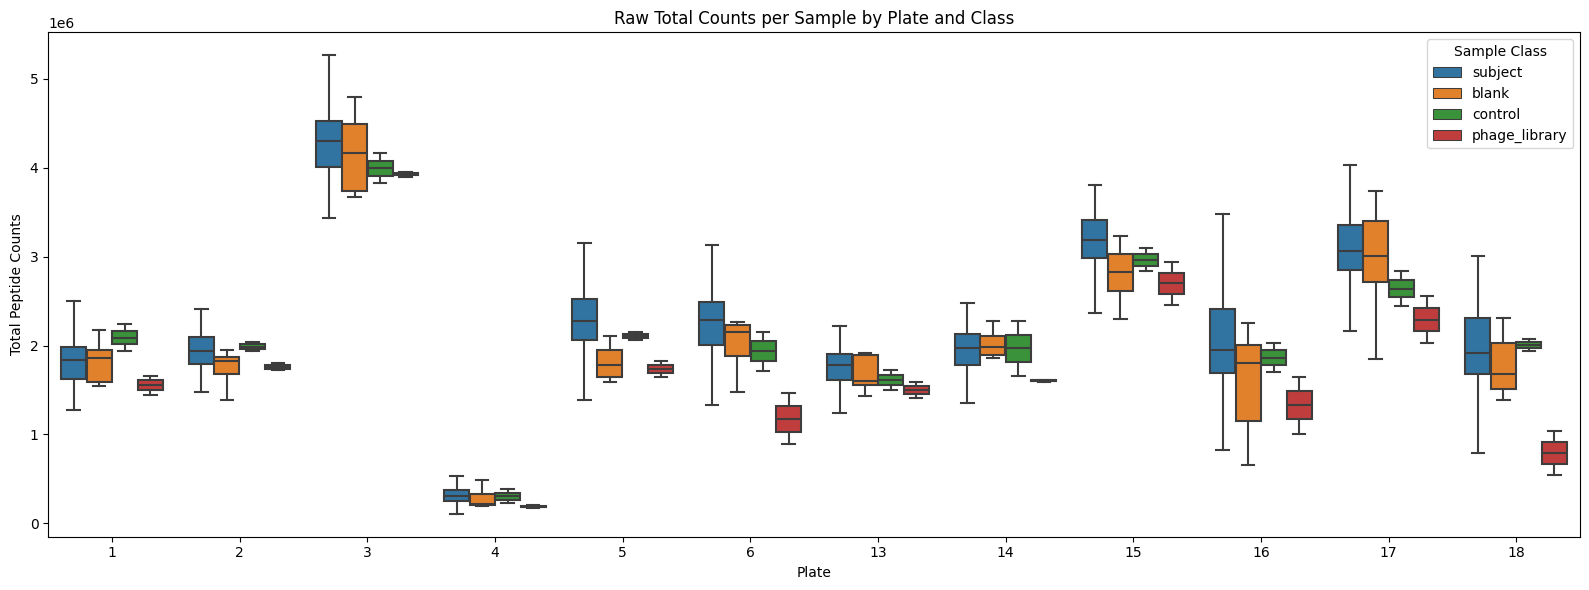

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total counts per sample
data_annot['total_count'] = data_annot[peptide_cols].sum(axis=1)

# Plot: Boxplot of total counts by plate and class
plt.figure(figsize=(16, 6))
sns.boxplot(
    data=data_annot,
    x='plate',
    y='total_count',
    hue='class',
    showfliers=False
)
plt.title('Raw Total Counts per Sample by Plate and Class')
plt.ylabel('Total Peptide Counts')
plt.xlabel('Plate')
plt.legend(title='Sample Class')
plt.tight_layout()
plt.show()

In [11]:
# Step 1: Compute median blank and phage library counts per peptide per plate
blank_medians = (
    data_annot[data_annot['class'] == 'blank']
    .groupby('plate')[peptide_cols]
    .median()
)

phage_medians = (
    data_annot[data_annot['class'] == 'phage_library']
    .groupby('plate')[peptide_cols]
    .median()
)

# Step 2: Compute reference phage library (median across all plates)
phage_ref = phage_medians.median(axis=0)

# Step 3: Compute scaling factors for each plate
epsilon = 1e-6
scaling_factors = (phage_ref / (phage_medians + epsilon)).median(axis=1)

# Step 4: Apply normalization to all samples
def normalize_row(row):
    plate = row['plate']
    raw_counts = row[peptide_cols].values.astype(float)
    blank = blank_medians.loc[plate].values
    scale = scaling_factors.loc[plate]
    norm_counts = (raw_counts - blank) * scale
    norm_counts = np.maximum(norm_counts, 0)  # No negative counts
    return pd.Series(norm_counts, index=peptide_cols)

# Apply normalization
norm_counts = data_annot.apply(normalize_row, axis=1)
data_annot_norm = data_annot.copy()
data_annot_norm[peptide_cols] = norm_counts

# Recalculate total counts after normalization
data_annot_norm['total_count'] = data_annot_norm[peptide_cols].sum(axis=1)

# Show scaling factors and a sample of normalized data
scaling_factors, data_annot_norm.head()

(plate
 1     0.952381
 2     0.867802
 3     0.375000
 4     7.999984
 5     0.860294
 6     1.329268
 13    1.833333
 14    0.923077
 15    0.500000
 16    1.166667
 17    0.711864
 18    2.041666
 dtype: float64,
         sample   subject  plate    1           2    3    4         5    6  \
 0     14078-01  14078-01      1  0.0    0.000000  0.0  0.0  0.952381  0.0   
 1  14078-01dup  14078-01      1  0.0   24.761902  0.0  0.0  0.000000  0.0   
 2     14118-01  14118-01      1  0.0    0.000000  0.0  0.0  0.952381  0.0   
 3  14118-01dup  14118-01      1  0.0    0.000000  0.0  0.0  1.904762  0.0   
 4     14127-01  14127-01      1  0.0  153.333319  0.0  0.0  0.000000  0.0   
 
            7  ...    128280     128281     128282    128283    128284  128285  \
 0   1.904762  ...  0.952381   0.000000   0.000000  0.000000  0.000000     0.0   
 1   0.000000  ...  0.000000   9.523809  54.285709  3.809523  0.000000     0.0   
 2  77.142850  ...  0.000000  19.999998   0.952381  0.000000  0.0000

In [12]:
# Prepare data for before/after boxplots
plot_df = pd.concat([
    data_annot.assign(norm='Raw'),
    data_annot_norm.assign(norm='Normalized')
])

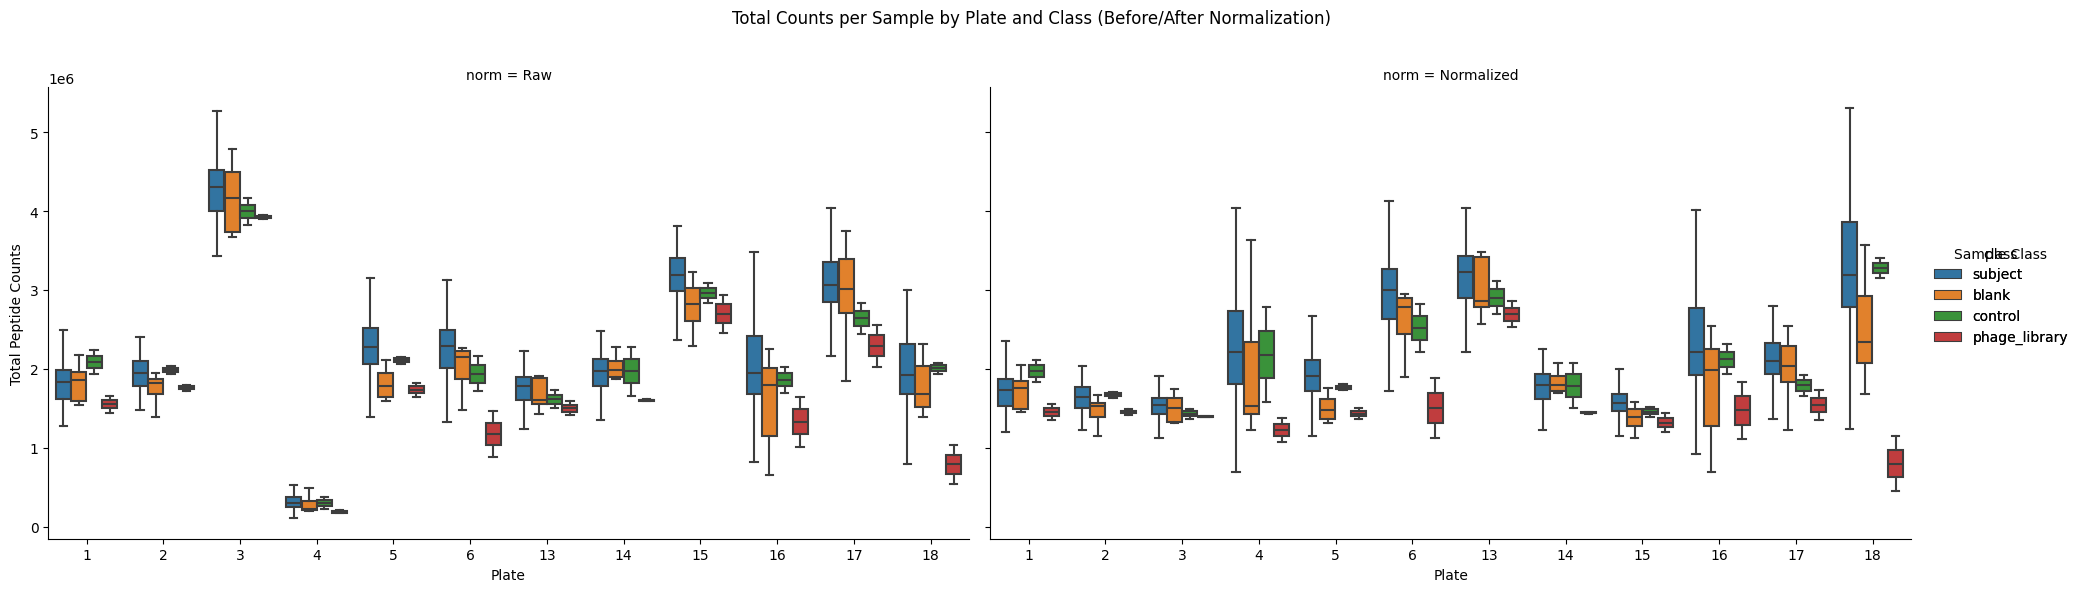

In [13]:
# Use seaborn's FacetGrid (catplot) for before/after comparison
g = sns.catplot(
    data=plot_df,
    x='plate',
    y='total_count',
    hue='class',
    col='norm',
    kind='box',
    showfliers=False,
    height=6,
    aspect=1.5
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Total Counts per Sample by Plate and Class (Before/After Normalization)')
g.set_axis_labels('Plate', 'Total Peptide Counts')
g.add_legend(title='Sample Class')
plt.show()

In [14]:
# Only keep subject samples for merging
subject_norm = data_annot_norm[data_annot_norm['class'] == 'subject']

# Merge replicates: mean of normalized counts per subject
subject_final = (
    subject_norm.groupby('subject')[peptide_cols]
    .mean()
    .reset_index()
)

# Show a sample of the final normalized subject matrix
subject_final.head()

,subject,1,10,100,1000,10000,10001,10002,10003,10004,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
0,024JCM,0.0,0.0,6.923077,0.461538,0.000000,0.000000,1.846154,0.000000,4.615384,...,0.000000,0.0,0.000000,0.0,0.461538,0.000000,0.0,0.0,0.000000,0.0
1,043MPL,0.0,0.0,17.416661,0.000000,0.916666,0.916666,4.583332,7.333331,3.666665,...,10.083330,0.0,0.916666,0.0,2.749999,0.000000,0.0,0.0,8.249997,0.0
2,074KBP,0.0,0.0,2.769231,0.000000,5.538461,0.923077,1.846154,0.923077,1.384615,...,0.000000,0.0,0.000000,0.0,6.000000,0.461538,0.0,0.0,0.000000,0.0
3,101VKC,0.0,0.0,0.000000,0.916666,0.000000,0.000000,6.416665,3.666665,0.000000,...,8.249997,0.0,0.916666,0.0,0.000000,0.000000,0.0,0.0,1.833333,0.0
4,108741,0.0,0.0,0.000000,0.000000,0.583333,0.000000,0.583333,2.916666,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0


In [17]:
subject_final.set_index('subject').head()

,1,10,100,1000,10000,10001,10002,10003,10004,10005,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
subject,,,,,,,,,,,,,,,,,,,,,
024JCM,0.0,0.0,6.923077,0.461538,0.000000,0.000000,1.846154,0.000000,4.615384,0.0,...,0.000000,0.0,0.000000,0.0,0.461538,0.000000,0.0,0.0,0.000000,0.0
043MPL,0.0,0.0,17.416661,0.000000,0.916666,0.916666,4.583332,7.333331,3.666665,0.0,...,10.083330,0.0,0.916666,0.0,2.749999,0.000000,0.0,0.0,8.249997,0.0
074KBP,0.0,0.0,2.769231,0.000000,5.538461,0.923077,1.846154,0.923077,1.384615,0.0,...,0.000000,0.0,0.000000,0.0,6.000000,0.461538,0.0,0.0,0.000000,0.0
101VKC,0.0,0.0,0.000000,0.916666,0.000000,0.000000,6.416665,3.666665,0.000000,0.0,...,8.249997,0.0,0.916666,0.0,0.000000,0.000000,0.0,0.0,1.833333,0.0
108741,0.0,0.0,0.000000,0.000000,0.583333,0.000000,0.583333,2.916666,0.000000,0.0,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0


In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# After normalization
normalized_data = subject_final.set_index('subject') # your normalized peptide counts
pca = PCA(n_components=2)
pca_result = pca.fit_transform(normalized_data)


IndexError: boolean index did not match indexed array along axis 0; size of axis is 502 but size of corresponding boolean axis is 1149

<Figure size 1000x600 with 0 Axes>

In [20]:
pca_result

array([[-12703.19060282, -28263.67514587],
       [  5506.68151543, -18113.85398645],
       [ -7324.68402703, -28045.045202  ],
       ...,
       [-23856.21416032, 100075.87431077],
       [ 47066.24631432,   7686.04335865],
       [ 38251.33307521,  28546.40205265]], shape=(502, 2))

In [ ]:
# Plot colored by plate
plt.figure(figsize=(10, 6))
for plate in sorted(data_annot['plate'].unique()):
    mask = data_annot['plate'] == plate
    plt.scatter(pca_result[mask, 0], pca_result[mask, 1], 
                label=f'Plate {plate}', alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.legend()
plt.title('PCA: Samples should cluster by biology, not plate')
plt.show()

In [21]:
data_annot['plate'].unique()

array([ 1,  2,  3,  4,  5,  6, 13, 14, 15, 16, 17, 18])

In [23]:
mask = data_annot['plate'] == plate
mask

0        True
1        True
2        True
3        True
4        True
        ...  
1144    False
1145    False
1146    False
1147    False
1148    False
Name: plate, Length: 1149, dtype: bool

In [26]:
pca_result[[mask,1]]

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.